In [1]:
pip install xgboost shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached numpy-2.4.6-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 1.2 MB/s  0:00:02 eta 0:00:010m
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 1.0 MB/s  0:00:41m0:00:0100:020m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 1.2 MB/s  0:00:02 eta 0:00:010m
Using cached numpy-2.4.6-cp313-cp313-macosx_14_0_arm64.whl (5.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.0
    Uninstalling numpy-2.5.0:
      Successfully uninstalled numpy-2.5.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [shap]7/8 [shap]st]]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/mart_ticket_modeling.csv")

print(df.shape)
df.head()

(10000, 52)


,ticket_id,booking_id,issue_category,contact_channel,priority_initial,guest_id,host_id,listing_id,nights,days_until_checkin_at_ticket,...,senior_agent_routing,rebooking_coupon_offered,repeat_contact_probability,repeat_contact_7d,escalation_probability,escalated,resolution_hours,csat_score,poor_csat,long_resolution
0,T000000,B000000,payment_problem,email,high,G00882,H00938,L02865,9,12,...,1,0,0.088,0,0.089,0,4.98,5,0,0
1,T000001,B000001,policy_question,chat,medium,G01659,H00095,L00570,2,2,...,1,0,0.223,0,0.114,0,4.80,5,0,0
2,T000002,B000002,refund_request,chat,medium,G03280,H00088,L01038,8,4,...,1,0,0.265,0,0.122,0,13.65,5,0,0
3,T000003,B000003,refund_request,phone,low,G03348,H01238,L00180,5,7,...,0,1,0.492,1,0.328,0,22.14,4,0,0
4,T000004,B000004,policy_question,chat,low,G03456,H00039,L00952,5,28,...,0,0,0.338,0,0.139,0,2.02,4,0,0


In [3]:
target = "repeat_contact_7d"

print(df[target].value_counts(normalize=True))

repeat_contact_7d
0    0.6285
1    0.3715
Name: proportion, dtype: float64


In [4]:
target = "repeat_contact_7d"

leakage_cols = [
    "repeat_contact_7d",
    "escalated",
    "poor_csat",
    "long_resolution",
    "csat_score",
    "resolution_hours",
    "repeat_contact_probability",
    "escalation_probability"
]

id_cols = [
    "ticket_id",
    "booking_id",
    "guest_id",
    "host_id",
    "listing_id"
]

drop_cols = [col for col in leakage_cols + id_cols if col in df.columns]

X = df.drop(columns=drop_cols)
y = df[target]

print("X shape:", X.shape)
print("Target rate:", y.mean())

X shape: (10000, 39)
Target rate: 0.3715


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(7500, 39) (2500, 39)
0.37146666666666667 0.3716


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

Categorical: ['issue_category', 'contact_channel', 'priority_initial', 'booking_status', 'cancelled_by', 'market', 'property_type', 'cancellation_policy']
Numeric: ['nights', 'days_until_checkin_at_ticket', 'total_booking_value', 'guest_account_age_days', 'guest_past_bookings_count', 'guest_past_support_tickets_12m', 'guest_past_refund_requests_12m', 'guest_lifetime_booking_value', 'guest_id_verified', 'host_superhost', 'host_response_rate', 'host_cancellation_rate_12m', 'host_avg_response_time_minutes', 'host_past_guest_complaints_12m', 'host_avg_rating', 'nightly_price', 'listing_review_score', 'listing_cleanliness_score', 'listing_accuracy_score', 'listing_review_count', 'instant_book_enabled', 'same_week_checkin_flag', 'strict_policy_flag', 'host_cancelled_booking_flag', 'high_value_booking_flag', 'sentiment_score', 'urgency_score', 'time_to_first_agent_response_minutes', 'message_count_first_30min', 'senior_agent_routing', 'rebooking_coupon_offered']


/var/folders/78/y2_1gdzn2kd4k_m309p88yxw0000gn/T/ipykernel_96521/1307077751.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()


In [7]:
from xgboost import XGBClassifier

positive_rate = y_train.mean()
negative_rate = 1 - positive_rate
scale_pos_weight = negative_rate / positive_rate

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_weight=20,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['issue_category','contact_channel','priority_initial',..., 'message_count_first_30min','senior_agent_routing', 'rebooking_coupon_offered']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (de

In [8]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_prob >= 0.50).astype(int)

print("XGBoost ROC-AUC:", round(roc_auc_score(y_test, xgb_prob), 4))
print("XGBoost PR-AUC:", round(average_precision_score(y_test, xgb_prob), 4))
print()
print(classification_report(y_test, xgb_pred))
print()
print(confusion_matrix(y_test, xgb_pred))

XGBoost ROC-AUC: 0.7061
XGBoost PR-AUC: 0.592

              precision    recall  f1-score   support

           0       0.75      0.72      0.74      1571
           1       0.56      0.59      0.57       929

    accuracy                           0.67      2500
   macro avg       0.65      0.66      0.65      2500
weighted avg       0.68      0.67      0.68      2500


[[1134  437]
 [ 380  549]]


In [9]:
eval_df = X_test.copy()
eval_df["actual_repeat_contact"] = y_test.values
eval_df["xgb_repeat_probability"] = xgb_prob

eval_df["risk_decile"] = pd.qcut(
    eval_df["xgb_repeat_probability"],
    q=10,
    labels=False,
    duplicates="drop"
)

decile_summary = (
    eval_df.groupby("risk_decile")
    .agg(
        tickets=("actual_repeat_contact", "count"),
        avg_predicted_risk=("xgb_repeat_probability", "mean"),
        actual_repeat_rate=("actual_repeat_contact", "mean")
    )
    .sort_index(ascending=False)
)

decile_summary

,tickets,avg_predicted_risk,actual_repeat_rate
risk_decile,,,
9,250,0.843632,0.708
8,250,0.731453,0.636
7,250,0.631300,0.488
6,250,0.535649,0.392
5,250,0.460197,0.308
4,250,0.398162,0.312
3,250,0.342767,0.244
2,250,0.289580,0.264
1,250,0.236394,0.232


In [10]:
overall_rate = y_test.mean()

decile_summary["lift_vs_average"] = (
    decile_summary["actual_repeat_rate"] / overall_rate
)

decile_summary

,tickets,avg_predicted_risk,actual_repeat_rate,lift_vs_average
risk_decile,,,,
9,250,0.843632,0.708,1.905274
8,250,0.731453,0.636,1.711518
7,250,0.631300,0.488,1.313240
6,250,0.535649,0.392,1.054898
5,250,0.460197,0.308,0.828848
4,250,0.398162,0.312,0.839612
3,250,0.342767,0.244,0.656620
2,250,0.289580,0.264,0.710441
1,250,0.236394,0.232,0.624327


In [11]:
decile_display = decile_summary.copy()

decile_display["avg_predicted_risk"] = (
    decile_display["avg_predicted_risk"] * 100
).round(2).astype(str) + "%"

decile_display["actual_repeat_rate"] = (
    decile_display["actual_repeat_rate"] * 100
).round(2).astype(str) + "%"

decile_display["lift_vs_average"] = decile_display["lift_vs_average"].round(2)

decile_display

,tickets,avg_predicted_risk,actual_repeat_rate,lift_vs_average
risk_decile,,,,
9,250,84.36%,70.8%,1.91
8,250,73.15%,63.6%,1.71
7,250,63.13%,48.8%,1.31
6,250,53.56%,39.2%,1.05
5,250,46.02%,30.8%,0.83
4,250,39.82%,31.2%,0.84
3,250,34.28%,24.4%,0.66
2,250,28.96%,26.4%,0.71
1,250,23.64%,23.2%,0.62


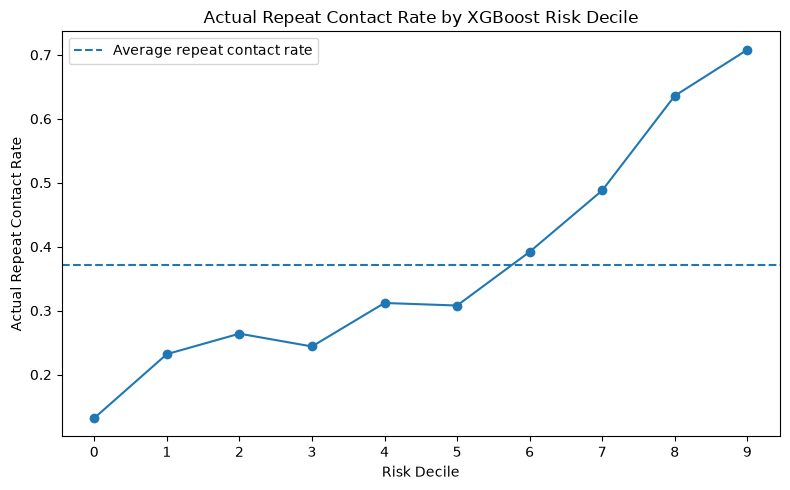

In [12]:
plot_data = decile_summary.sort_index()

plt.figure(figsize=(8, 5))
plt.plot(
    plot_data.index.astype(str),
    plot_data["actual_repeat_rate"],
    marker="o"
)
plt.axhline(
    overall_rate,
    linestyle="--",
    label="Average repeat contact rate"
)
plt.title("Actual Repeat Contact Rate by XGBoost Risk Decile")
plt.xlabel("Risk Decile")
plt.ylabel("Actual Repeat Contact Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
fitted_preprocessor = xgb_model.named_steps["preprocessor"]

num_features = numeric_cols

cat_encoder = (
    fitted_preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
)

cat_features = cat_encoder.get_feature_names_out(categorical_cols).tolist()

feature_names = num_features + cat_features

len(feature_names)

67

In [15]:
xgb_clf = xgb_model.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_clf.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(25)

,feature,importance
25,sentiment_score,0.049849
26,urgency_score,0.040132
37,issue_category_safety_issue,0.028970
32,issue_category_host_cancellation,0.028800
21,same_week_checkin_flag,0.022392
29,senior_agent_routing,0.022328
66,cancellation_policy_strict,0.021603
5,guest_past_support_tickets_12m,0.019789
1,days_until_checkin_at_ticket,0.019030
22,strict_policy_flag,0.018365


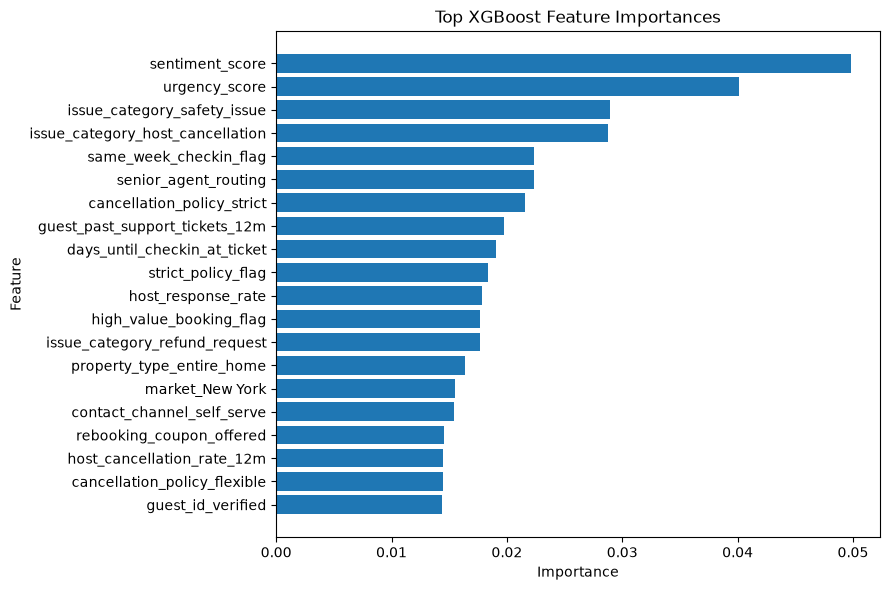

In [16]:
top_n = 20

plot_data = importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(plot_data["feature"], plot_data["importance"])
plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [17]:
import shap

X_test_transformed = fitted_preprocessor.transform(X_test)

# Convert sparse matrix to dense if needed
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

explainer = shap.TreeExplainer(xgb_clf)

# Use a sample for speed
sample_size = min(1000, X_test_transformed.shape[0])
X_shap_sample = X_test_transformed[:sample_size]

shap_values = explainer.shap_values(X_shap_sample)

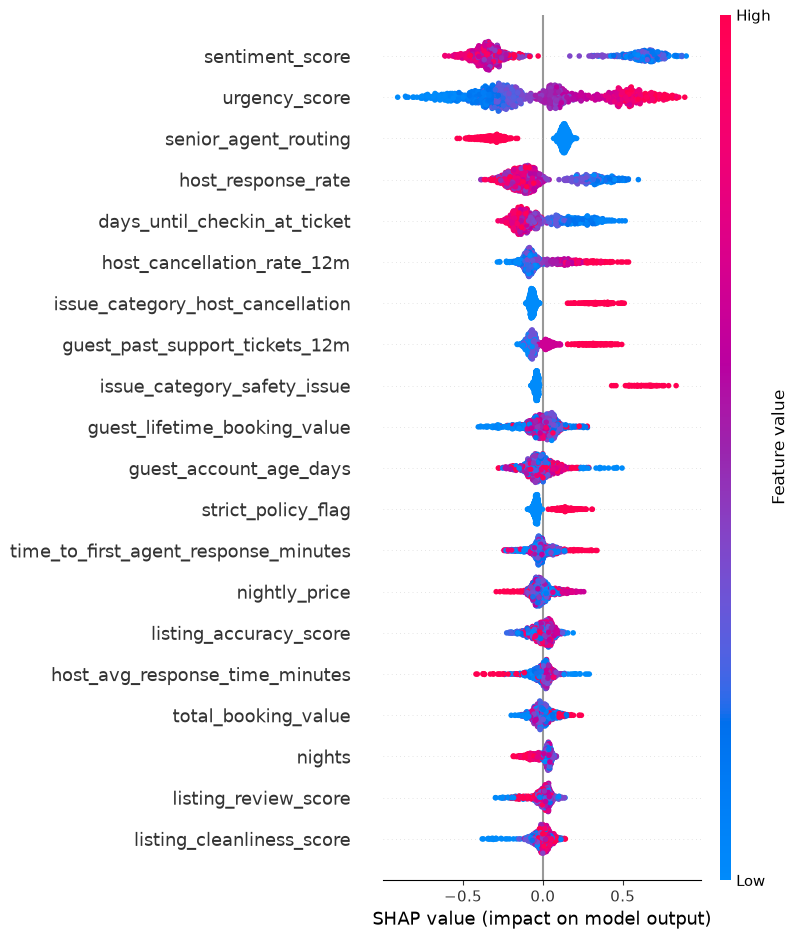

In [18]:
shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=feature_names,
    max_display=20
)

In [19]:
high_risk_idx = np.argmax(xgb_prob)

single_ticket = X_test.iloc[[high_risk_idx]]
single_prob = xgb_prob[high_risk_idx]

print("Predicted repeat-contact risk:", round(single_prob, 3))
single_ticket.T.head(30)

Predicted repeat-contact risk: 0.951


,3174
issue_category,safety_issue
contact_channel,email
priority_initial,low
nights,4
days_until_checkin_at_ticket,1
total_booking_value,1018.02
booking_status,completed
cancelled_by,none
guest_account_age_days,1032
guest_past_bookings_count,7


In [20]:
single_transformed = fitted_preprocessor.transform(single_ticket)

if hasattr(single_transformed, "toarray"):
    single_transformed = single_transformed.toarray()

single_shap_values = explainer.shap_values(single_transformed)

single_explanation = pd.DataFrame({
    "feature": feature_names,
    "shap_value": single_shap_values[0],
    "feature_value": single_transformed[0]
})

single_explanation["abs_shap"] = single_explanation["shap_value"].abs()

single_explanation.sort_values("abs_shap", ascending=False).head(15)

,feature,shap_value,feature_value,abs_shap
26,urgency_score,0.693296,0.931,0.693296
37,issue_category_safety_issue,0.556615,1.000,0.556615
25,sentiment_score,0.544366,-1.000,0.544366
1,days_until_checkin_at_ticket,0.306865,1.000,0.306865
5,guest_past_support_tickets_12m,0.294539,3.000,0.294539
10,host_response_rate,0.248301,0.685,0.248301
27,time_to_first_agent_response_minutes,0.137700,45.500,0.137700
29,senior_agent_routing,0.115317,0.000,0.115317
11,host_cancellation_rate_12m,0.096137,0.080,0.096137
60,market_Seattle,0.078133,1.000,0.078133


In [21]:
def create_reason_codes(row):
    reasons = []

    if row.get("urgency_score", 0) >= 0.75:
        reasons.append("High urgency ticket")

    if row.get("sentiment_score", 0) <= -0.50:
        reasons.append("Negative customer sentiment")

    if row.get("same_week_checkin_flag", 0) == 1:
        reasons.append("Check-in within 7 days")

    if row.get("issue_category") in ["host_cancellation", "safety_issue", "listing_not_as_described"]:
        reasons.append(f"High-risk issue type: {row.get('issue_category')}")

    if row.get("host_cancellation_rate_12m", 0) >= 0.08:
        reasons.append("Host has elevated cancellation history")

    if row.get("host_response_rate", 1) <= 0.75:
        reasons.append("Host response rate is low")

    if row.get("strict_policy_flag", 0) == 1:
        reasons.append("Strict cancellation policy")

    return reasons[:5]

In [22]:
policy_df = X_test.copy()

policy_df["ticket_id"] = df.loc[X_test.index, "ticket_id"].values
policy_df["actual_repeat_contact"] = y_test.values
policy_df["predicted_repeat_risk"] = xgb_prob

policy_df["risk_tier"] = pd.qcut(
    policy_df["predicted_repeat_risk"],
    q=[0, 0.70, 0.90, 1.0],
    labels=["low", "medium", "high"]
)

policy_df["reason_codes"] = policy_df.apply(create_reason_codes, axis=1)

policy_df[
    [
        "ticket_id",
        "issue_category",
        "predicted_repeat_risk",
        "risk_tier",
        "reason_codes",
        "actual_repeat_contact"
    ]
].sort_values("predicted_repeat_risk", ascending=False).head(20)

,ticket_id,issue_category,predicted_repeat_risk,risk_tier,reason_codes,actual_repeat_contact
3174,T003174,safety_issue,0.951402,high,"[High urgency ticket, Negative customer sentim...",1
9366,T009366,safety_issue,0.947850,high,"[High urgency ticket, Negative customer sentim...",1
4743,T004743,safety_issue,0.943876,high,"[High urgency ticket, Negative customer sentim...",0
4178,T004178,host_cancellation,0.939133,high,"[High urgency ticket, Check-in within 7 days, ...",1
319,T000319,safety_issue,0.934058,high,"[High urgency ticket, Negative customer sentim...",0
4731,T004731,safety_issue,0.927208,high,"[High urgency ticket, Negative customer sentim...",0
8525,T008525,host_cancellation,0.925940,high,"[Negative customer sentiment, High-risk issue ...",1
1943,T001943,safety_issue,0.921532,high,"[High urgency ticket, Negative customer sentim...",1
8879,T008879,host_cancellation,0.920091,high,"[Negative customer sentiment, High-risk issue ...",1
1909,T001909,listing_not_as_described,0.918158,high,"[Negative customer sentiment, Check-in within ...",1


#Step 4O — Policy simulation

In [23]:
threshold_90 = policy_df["predicted_repeat_risk"].quantile(0.90)

policy_df["recommend_senior_routing"] = (
    policy_df["predicted_repeat_risk"] >= threshold_90
).astype(int)

simulation = policy_df.groupby("recommend_senior_routing").agg(
    tickets=("ticket_id", "count"),
    repeat_contact_rate=("actual_repeat_contact", "mean"),
    avg_predicted_risk=("predicted_repeat_risk", "mean")
)

simulation

,tickets,repeat_contact_rate,avg_predicted_risk
recommend_senior_routing,,,
0,2250,0.334222,0.421108
1,250,0.708000,0.843632


In [24]:
total_repeat_contacts = policy_df["actual_repeat_contact"].sum()

captured_repeat_contacts = policy_df.loc[
    policy_df["recommend_senior_routing"] == 1,
    "actual_repeat_contact"
].sum()

coverage = captured_repeat_contacts / total_repeat_contacts

print(f"Top 10% routing captures {coverage:.2%} of repeat-contact cases.")

Top 10% routing captures 19.05% of repeat-contact cases.


Final Summary

In [25]:
print("Step 4 Summary")
print("-" * 60)

print(f"Model: XGBoost")
print(f"Target: {target}")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_prob):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, xgb_prob):.4f}")
print()

top_decile = decile_summary.sort_index(ascending=False).iloc[0]

print(f"Overall repeat-contact rate: {overall_rate:.2%}")
print(f"Top-risk decile repeat-contact rate: {top_decile['actual_repeat_rate']:.2%}")
print(f"Top-risk decile lift: {top_decile['lift_vs_average']:.2f}x")
print()

print("Business interpretation:")
print(
    "The XGBoost model identifies support tickets with elevated repeat-contact risk. "
    "Top drivers include urgency, sentiment, issue type, booking timing, host reliability, "
    "listing quality, and prior guest support history. "
    "The output can support risk-tiering, reason codes, and targeted senior-agent routing."
)

Step 4 Summary
------------------------------------------------------------
Model: XGBoost
Target: repeat_contact_7d
ROC-AUC: 0.7061
PR-AUC: 0.5920

Overall repeat-contact rate: 37.16%
Top-risk decile repeat-contact rate: 70.80%
Top-risk decile lift: 1.91x

Business interpretation:
The XGBoost model identifies support tickets with elevated repeat-contact risk. Top drivers include urgency, sentiment, issue type, booking timing, host reliability, listing quality, and prior guest support history. The output can support risk-tiering, reason codes, and targeted senior-agent routing.
